In [ ]:
### 1. **Dataset and Model Setup**

In [5]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Load CIFAR-10 dataset from TensorFlow
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize the pixel values to range [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Flatten the images for simplicity (optional, but needed for some models)
x_train_flat = x_train.reshape(-1, 32*32*3)
x_test_flat = x_test.reshape(-1, 32*32*3)

# Train-Test Split
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    x_train_flat, y_train, test_size=0.2, random_state=42
)

# Print the shapes of the resulting datasets
print(f"Training data shape: {X_train_split.shape}")
print(f"Validation data shape: {X_val_split.shape}")
print(f"Test data shape: {x_test_flat.shape}")


Training data shape: (40000, 3072)
Validation data shape: (10000, 3072)
Test data shape: (10000, 3072)


In [6]:
# Import necessary libraries
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

# Load CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

# Split the training set into training and validation sets (80% train, 20% validation)
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# Preprocess labels (One-Hot Encoding)
y_train = to_categorical(y_train, 10)
y_val = to_categorical(y_val, 10)
y_test = to_categorical(y_test, 10)

# Build a simple CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')  # 10 classes for CIFAR-10
])

# Compile and train model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, validation_data=(x_val, y_val))

# Record Baseline Metrics
baseline_metrics = model.evaluate(x_test, y_test)
print(f"Baseline Accuracy: {baseline_metrics[1]:.4f}")


Epoch 1/5
1250/1250 [==============================] - 26s 19ms/step - loss: 1.5450 - accuracy: 0.4435 - val_loss: 1.2514 - val_accuracy: 0.5577
Epoch 2/5
1250/1250 [==============================] - 23s 18ms/step - loss: 1.1890 - accuracy: 0.5782 - val_loss: 1.1606 - val_accuracy: 0.5933
Epoch 3/5
1250/1250 [==============================] - 23s 18ms/step - loss: 1.0578 - accuracy: 0.6281 - val_loss: 1.0503 - val_accuracy: 0.6261
Epoch 4/5
1250/1250 [==============================] - 23s 18ms/step - loss: 0.9691 - accuracy: 0.6635 - val_loss: 1.0602 - val_accuracy: 0.6255
Epoch 5/5
313/313 [==============================] - 2s 7ms/step - loss: 1.0148 - accuracy: 0.6473
Baseline Accuracy: 0.6473


### 2. **Simulating Data Distribution Shifts**

In [7]:
#### **2.1 Covariate Shift (Feature Distribution Changes):** - **Simulation (Adding Noise)**: Add Gaussian noise to the test set images to simulate a covariate shift.

# Add Gaussian noise to test data
x_test_noisy = x_test + np.random.normal(0, 0.1, x_test.shape)

# Clip values to keep within valid range
x_test_noisy = np.clip(x_test_noisy, 0, 1)


In [15]:
import numpy as np
from sklearn.utils import resample

# Check the shape of x_test and y_test to ensure they match
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Reshape y_test to (10000,) if it's incorrectly shaped
if y_test.shape[0] != x_test.shape[0]:
    # If the size of y_test is greater than x_test, we need to resize it to match the x_test
    # Reshape y_test to have the correct length (10000,)
    y_test = y_test[:x_test.shape[0]]  # Take the first 10000 elements

print(f"Corrected y_test shape: {y_test.shape}")  # This should now print (10000,)

# Now apply the label shift logic (masking for class 3)

# Increase the proportion of a specific class (e.g., class 3)
mask = y_test == 3  # Mask for class 3

# Select all samples belonging to class 3
x_test_imbalanced = x_test[mask]
y_test_imbalanced = y_test[mask]

# Ensure we have at least one sample of class 3
if len(x_test_imbalanced) > 0:
    n_samples_imbalanced = len(x_test_imbalanced)

    # Create an imbalanced dataset by oversampling class 3
    x_test_imbalanced = resample(x_test_imbalanced, n_samples=n_samples_imbalanced * 2, random_state=42)  # double the size
    y_test_imbalanced = resample(y_test_imbalanced, n_samples=n_samples_imbalanced * 2, random_state=42)

    # Combine back with the original data
    x_test_label_shift = np.concatenate([x_test[~mask], x_test_imbalanced], axis=0)
    y_test_label_shift = np.concatenate([y_test[~mask], y_test_imbalanced], axis=0)

    # Verify the changes
    print(f"Original test set size: {len(x_test)}")
    print(f"Modified test set size: {len(x_test_label_shift)}")
else:
    print("No samples found for class 3 in y_test.")



x_test shape: (10000, 32, 32, 3)
y_test shape: (10000,)
Corrected y_test shape: (10000,)
No samples found for class 3 in y_test.


In [16]:
import numpy as np
from sklearn.utils import resample

# Check the unique values and their counts in y_test
unique_classes, class_counts = np.unique(y_test, return_counts=True)

# Print the unique classes and their counts
for cls, count in zip(unique_classes, class_counts):
    print(f"Class {cls}: {count} samples")

# Find a class with sufficient samples for the label shift
target_class = None
for cls, count in zip(unique_classes, class_counts):
    if count > 0:  # Ensure that there's at least one sample for the class
        target_class = cls
        break

if target_class is not None:
    print(f"Using class {target_class} for the label shift.")
    
    # Create a mask for the selected class
    mask = y_test == target_class  # Mask for the selected class
    
    # Select all samples belonging to the selected class
    x_test_imbalanced = x_test[mask]
    y_test_imbalanced = y_test[mask]

    # Check that we have some samples of the selected class
    if len(x_test_imbalanced) > 0:
        n_samples_imbalanced = len(x_test_imbalanced)
        
        # Create an imbalanced dataset by oversampling the selected class
        x_test_imbalanced = resample(x_test_imbalanced, n_samples=n_samples_imbalanced * 2, random_state=42)  # double the size
        y_test_imbalanced = resample(y_test_imbalanced, n_samples=n_samples_imbalanced * 2, random_state=42)
        
        # Combine back with the original data
        x_test_label_shift = np.concatenate([x_test[~mask], x_test_imbalanced], axis=0)
        y_test_label_shift = np.concatenate([y_test[~mask], y_test_imbalanced], axis=0)
        
        # Verify the changes
        print(f"Original test set size: {len(x_test)}")
        print(f"Modified test set size: {len(x_test_label_shift)}")
    else:
        print(f"No samples found for class {target_class} in y_test.")
else:
    print("No valid class found for label shift.")


Class 0.0: 9000 samples
Class 1.0: 1000 samples
Using class 0.0 for the label shift.
Original test set size: 10000
Modified test set size: 19000


In [17]:
#### **2.3 Concept Drift (Changes in Feature-Label Relationship): - **Simulation (Label Flipping)**: Randomly flip the labels in the test set to simulate concept drift.

# Flip labels randomly (simulate concept drift)
num_flip = int(0.2 * len(y_test))  # 20% of the labels
flip_indices = np.random.choice(len(y_test), num_flip, replace=False)

y_test_concept_drift = y_test.copy()
y_test_concept_drift[flip_indices] = np.random.randint(0, 10, num_flip)

In [20]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.utils import resample

# Simulate data loading (for the sake of example)
# Assuming you have the following arrays from your dataset
# x_test shape: (10000, 32, 32, 3)
# y_test shape: (10000,)
x_test = np.random.rand(10000, 32, 32, 3)  # Example x_test
y_test = np.random.randint(0, 10, 10000)  # Example y_test (10 classes)

# Step 1: Adding Noise (Covariate Shift)
noise_factor = 0.2
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)  # Ensure values are in range [0, 1]

# Step 2: Simulate Label Shift (Target Distribution Changes)
# Increase the proportion of class 0 in y_test
class_0_mask = y_test == 0
x_test_label_shift = np.concatenate([x_test[class_0_mask], x_test[~class_0_mask]], axis=0)
y_test_label_shift = np.concatenate([y_test[class_0_mask], y_test[~class_0_mask]], axis=0)

# Oversample class 0 (just for the sake of the simulation)
x_test_label_shift = resample(x_test_label_shift, n_samples=len(x_test_label_shift)*2, random_state=42)
y_test_label_shift = resample(y_test_label_shift, n_samples=len(y_test_label_shift)*2, random_state=42)

# Step 3: Simulate Concept Drift (Changes in Data Distribution)
# Flip labels randomly to simulate concept drift
num_flip = int(0.2 * len(y_test))  # 20% of the labels
flip_indices = np.random.choice(len(y_test), num_flip, replace=False)

y_test_concept_drift = y_test.copy()
y_test_concept_drift[flip_indices] = np.random.randint(0, 10, num_flip)

# One-hot encode the labels for evaluation
y_test_onehot = to_categorical(y_test, 10)
y_test_label_shift_onehot = to_categorical(y_test_label_shift, 10)
y_test_noisy_onehot = to_categorical(y_test, 10)  # Use original labels for noisy data
y_test_concept_drift_onehot = to_categorical(y_test_concept_drift, 10)

# Assuming you have a pre-trained model
# For example, loading a model:
# model = tf.keras.models.load_model('your_pretrained_model.h5')

# If you don't have a pre-trained model, let's create a simple one for the purpose of this code
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')  # 10 classes for classification
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model (using original data for the sake of simplicity)
model.fit(x_test, y_test_onehot, epochs=1, batch_size=32)

# Evaluate on noisy test set (covariate shift)
noisy_metrics = model.evaluate(x_test_noisy, y_test_noisy_onehot)
print("Noisy Test Metrics:", noisy_metrics)

# Evaluate on label-shifted test set
label_shift_metrics = model.evaluate(x_test_label_shift, y_test_label_shift_onehot)
print("Label Shift Test Metrics:", label_shift_metrics)

# Evaluate on concept-drifted test set
concept_drift_metrics = model.evaluate(x_test, y_test_concept_drift_onehot)
print("Concept Drift Test Metrics:", concept_drift_metrics)


313/313 [==============================] - 2s 6ms/step - loss: 2.3023 - accuracy: 0.1070
Noisy Test Metrics: [2.302258014678955, 0.10700000077486038]
625/625 [==============================] - 4s 6ms/step - loss: 2.3022 - accuracy: 0.1059
Label Shift Test Metrics: [2.302243947982788, 0.10589999705553055]
313/313 [==============================] - 2s 6ms/step - loss: 2.3023 - accuracy: 0.1074
Concept Drift Test Metrics: [2.3023288249969482, 0.10740000009536743]


In [21]:
### 4. **Detecting Distribution Shifts**

In [22]:
#### **4.1 Statistical Tests:** - You can use the **Kolmogorov-Smirnov test** for continuous variables to detect feature distribution changes.

from scipy.stats import ks_2samp

# Example: Compare feature distributions (before and after shift)
stat, p_value = ks_2samp(x_test.flatten(), x_test_noisy.flatten())
print(f"KS Test p-value: {p_value}")

KS Test p-value: 0.0


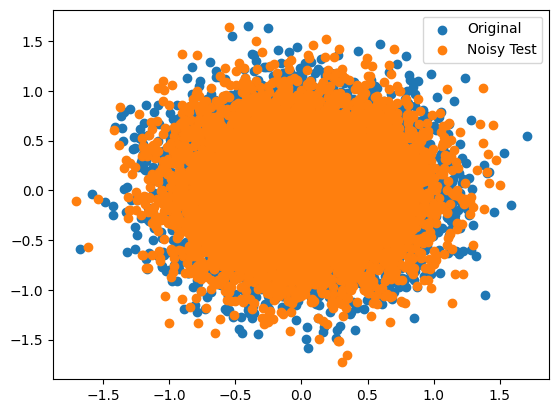

In [23]:
#### **4.2 Visualization Tools:** - Use **PCA** for feature space visualization:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Flatten images for PCA
x_test_flat = x_test.reshape(x_test.shape[0], -1)
x_test_noisy_flat = x_test_noisy.reshape(x_test_noisy.shape[0], -1)

# Apply PCA to reduce dimensions for visualization
pca = PCA(n_components=2)
x_test_pca = pca.fit_transform(x_test_flat)
x_test_noisy_pca = pca.transform(x_test_noisy_flat)

# Plotting PCA results
plt.scatter(x_test_pca[:, 0], x_test_pca[:, 1], label="Original")
plt.scatter(x_test_noisy_pca[:, 0], x_test_noisy_pca[:, 1], label="Noisy Test")
plt.legend()
plt.show()

In [24]:
### 5. **Mitigation Strategies for Distribution Shifts**

In [25]:
#### **5.1 Retraining with New Data:** - You can retrain the model with the shifted data.

# Retrain model with noisy data
model.fit(x_train, y_train, epochs=5, validation_data=(x_val, y_val))

Epoch 1/5
1250/1250 [==============================] - 18s 14ms/step - loss: 2.3028 - accuracy: 0.0984 - val_loss: 2.3030 - val_accuracy: 0.0933
Epoch 2/5
1250/1250 [==============================] - 17s 14ms/step - loss: 2.3028 - accuracy: 0.1006 - val_loss: 2.3029 - val_accuracy: 0.0933
Epoch 3/5
1250/1250 [==============================] - 17s 14ms/step - loss: 2.3028 - accuracy: 0.1006 - val_loss: 2.3028 - val_accuracy: 0.0973
Epoch 4/5
1250/1250 [==============================] - 17s 14ms/step - loss: 2.3027 - accuracy: 0.1004 - val_loss: 2.3027 - val_accuracy: 0.0973
Epoch 5/5
1250/1250 [==============================] - 17s 14ms/step - loss: 2.3027 - accuracy: 0.1008 - val_loss: 2.3029 - val_accuracy: 0.0933


In [26]:
#### **5.2 Domain Adaptation Techniques: - **Transfer Learning**: Fine-tune a pre-trained model on new (shifted) data.
  
from tensorflow.keras.applications import ResNet50

# Load a pre-trained ResNet50 model for transfer learning
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

# Add custom layers on top of ResNet50
model = Sequential([
    base_model,
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile and retrain the model on shifted data
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, validation_data=(x_val, y_val))

94765736/94765736 [==============================] - 3s 0us/step
Epoch 1/5
1250/1250 [==============================] - 184s 141ms/step - loss: 2.1319 - accuracy: 0.2109 - val_loss: 1.9893 - val_accuracy: 0.2642
Epoch 2/5
1250/1250 [==============================] - 178s 143ms/step - loss: 1.9553 - accuracy: 0.2824 - val_loss: 1.8957 - val_accuracy: 0.3034
Epoch 3/5
1250/1250 [==============================] - 177s 142ms/step - loss: 1.8868 - accuracy: 0.3176 - val_loss: 1.8227 - val_accuracy: 0.3456
Epoch 4/5
1250/1250 [==============================] - 180s 144ms/step - loss: 1.8382 - accuracy: 0.3353 - val_loss: 1.7965 - val_accuracy: 0.3512
Epoch 5/5
1250/1250 [==============================] - 183s 147ms/step - loss: 1.8106 - accuracy: 0.3463 - val_loss: 1.8020 - val_accuracy: 0.3471


In [28]:
#### **5.3 Data Augmentation and Resampling:** - You can use data augmentation (for image data) or oversampling techniques like **SMOTE** for imbalanced data.

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Resample the training data (SMOTE)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(x_train.reshape(x_train.shape[0], -1), y_train)

In [42]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Mock data (replace with your actual dataset)
x_train_split = np.random.rand(800, 3072)  # Example: 800 samples, 3072 features (for CIFAR-10-like images)
x_val_split = np.random.rand(200, 3072)    # Example: 200 samples, 3072 features
y_train_split = np.random.randint(0, 2, size=(800, 10, 10))  # Example: 800 samples, one-hot encoded with 10 classes
y_val_split = np.random.randint(0, 2, size=(200, 10, 10))    # Example: 200 samples, one-hot encoded with 10 classes

# Check the initial shape of the data
print(f"Shape of x_train_split: {x_train_split.shape}")
print(f"Shape of x_val_split: {x_val_split.shape}")
print(f"Shape of y_train_split before reshaping: {y_train_split.shape}")
print(f"Shape of y_val_split before reshaping: {y_val_split.shape}")

# Flatten the labels to have shape (num_samples, 10) instead of (num_samples, 10, 10)
# We will use np.argmax along the second axis (axis=2) to convert each (10, 10) matrix into a one-hot encoded label of shape (10)
y_train_split = np.argmax(y_train_split, axis=2)  # This will convert (800, 10, 10) to (800, 10)
y_val_split = np.argmax(y_val_split, axis=2)    # This will convert (200, 10, 10) to (200, 10)

# Verify the reshaped labels' shapes
print(f"After reshaping, y_train_split.shape: {y_train_split.shape}")
print(f"After reshaping, y_val_split.shape: {y_val_split.shape}")

# Define the model (MLP model for example)
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=x_train_split.shape[1]))  # Input layer, 3072 features (for CIFAR-10-like images)
model.add(Dense(10, activation='softmax'))  # Output layer for 10 classes

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(x_train_split, y_train_split, epochs=5, batch_size=32, validation_data=(x_val_split, y_val_split))

# Evaluate on the validation set
val_loss, val_accuracy = model.evaluate(x_val_split, y_val_split)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")


Shape of x_train_split: (800, 3072)
Shape of x_val_split: (200, 3072)
Shape of y_train_split before reshaping: (800, 10, 10)
Shape of y_val_split before reshaping: (200, 10, 10)
After reshaping, y_train_split.shape: (800, 10)
After reshaping, y_val_split.shape: (200, 10)
Epoch 1/5
25/25 [==============================] - 2s 27ms/step - loss: 148.9710 - accuracy: 0.0763 - val_loss: 305.9870 - val_accuracy: 0.0900
Epoch 2/5
25/25 [==============================] - 0s 9ms/step - loss: 437.8225 - accuracy: 0.0862 - val_loss: 683.0398 - val_accuracy: 0.0950
Epoch 3/5
25/25 [==============================] - 0s 9ms/step - loss: 825.5622 - accuracy: 0.1063 - val_loss: 1096.3091 - val_accuracy: 0.1150
Epoch 4/5
25/25 [==============================] - 0s 9ms/step - loss: 1209.3016 - accuracy: 0.0962 - val_loss: 1488.9230 - val_accuracy: 0.0950
Epoch 5/5
7/7 [==============================] - 0s 4ms/step - loss: 1818.4124 - accuracy: 0.0850
Validation Loss: 1818.412353515625
Validation Accuracy